<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/may_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

### Importamos las librerías necesarias

In [1]:
# Se importan las mismas librerías utilizadas en clase para el armado del dataset,
# la tokenización, el armado de secuencias, el modelo Seq2Seq y su entrenamiento
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

I0000 00:00:1787355085.919637   35380 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787355086.897532   35380 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787355089.499118   35380 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Descargamos el dataset de traducción Español-Inglés

In [2]:
# Se descarga y descomprime el mismo dataset spa-eng utilizado en clase
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

print(f"Total de líneas disponibles en el dataset: {len(lines)}")

Total de líneas disponibles en el dataset: 118964


### Ampliamos el conjunto de datos y fijamos la semilla

En la clase se trabajó con `MAX_NUM_SENTENCES = 10000`. Acá se incrementa ese valor para que el modelo cuente con más ejemplos de entrenamiento, tal como pide la consigna.

In [3]:
# Se aumenta la cantidad de oraciones respecto de la clase (10.000 -> 40.000)
# Se hace de este modo porque un dataset más grande le da al modelo más variedad de vocabulario
# y de estructuras gramaticales para aprender, lo que en principio debería mejorar la generalización
MAX_NUM_SENTENCES = 40000

np.random.seed(40)
np.random.shuffle(lines)

### Cargamos los pares de oraciones

In [4]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 40000


In [5]:
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Somebody stole my car.
Alguien robó mi auto. <eos>
<sos> Alguien robó mi auto.


### Aplicamos tokenización

Se amplía `MAX_VOCAB_SIZE` respecto del valor de la clase (8.000 -> 15.000) porque, al haber más oraciones, también aparecen muchas más palabras distintas y no queremos perder cobertura de vocabulario.

In [6]:
# Se aumenta el vocabulario máximo porque al ampliar el dataset aparecen muchas más palabras únicas
MAX_VOCAB_SIZE = 15000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

# Solo se tomarán en cuenta las palabras más frecuentes y se eliminan signos de puntuación
output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)

output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")

Vocabulario EN: 9120 | ES: 16144


### Definimos la longitud máxima de las secuencias

En la clase se usaba una longitud fija (20 para el input, 22 para el output). Acá se calcula en base al percentil 95 de la longitud real de las oraciones tokenizadas. Se hace de este modo porque así se cubre a casi todo el dataset con secuencias más largas que las de la clase, sin que un puñado de oraciones extremadamente largas fuerce un padding excesivo para el resto de los ejemplos.

In [7]:
# Se calcula la longitud de cada secuencia ya tokenizada
input_lengths  = [len(seq) for seq in input_integer_seq]
output_lengths = [len(seq) for seq in output_integer_seq]

# Se toma el percentil 95 como longitud máxima de cada secuencia
max_input_len = int(np.percentile(input_lengths, 95))
max_out_len   = int(np.percentile(output_lengths, 95))

print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")
print("(en la clase se usaban 20 y 22 respectivamente, acá trabajamos con secuencias más largas)")

max_input_len=11  max_out_len=12
(en la clase se usaban 20 y 22 respectivamente, acá trabajamos con secuencias más largas)


### Aplicamos padding a las secuencias

In [8]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

In [9]:
print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[   0    0    0    0    0    0    0  932 1082   18   95]
[8346  156 1126   22  208    0    0    0    0    0    0    0]
[ 156 1126   22  208    1    0    0    0    0    0    0    0]


### Definimos función para obtener un tf.data.Dataset

Se reutiliza la misma función que en la clase: arma batches de (encoder_in, decoder_in) contra targets codificados en one-hot.

In [10]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):

    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)          # shape (max_out_len, num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

### Aplicamos la función en el dataset para obtener el train y validation set

In [11]:
BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

print(f"Ejemplos de train: {split_idx} | Ejemplos de validation: {len(encoder_input_sequences) - split_idx}")

Ejemplos de train: 34000 | Ejemplos de validation: 6000


E0000 00:00:1787355095.603304   35380 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Definimos función para descargar los embeddings de GloVe

In [12]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

gloveembedding.pkl ya disponible.


### Definimos función para cargar los embeddings de GloVe

In [13]:
def load_glove_embeddings(pkl_path):
    """Carga el pickle de GloVe y devuelve (embeddings, word2idx)."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

### Definimos función para obtener el embedding por palabra

In [14]:
def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

### Definimos función para armar la matriz de embeddings

In [15]:
def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [16]:
EMBED_DIM = 50
nb_words  = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Embeddings nulos: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")

Embeddings nulos: 473


### **Modelo Seq2Seq**

Definimos función para armar el encoder. Se agrega el parámetro `dropout` (además de `n_units`) para poder ajustarlo junto con el número de unidades LSTM durante la comparación de hiperparámetros. La función devuelve (encoder_inputs, encoder_states, encoder_emb_layer, encoder_lstm_layer) para poder reusar las capas en el modelo de inferencia.

In [17]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units, dropout=0.3):

    enc_inputs = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,                                    # se congela porque son embeddings preentrenados
        name='encoder_embedding'
    )
    enc_emb = Dropout(dropout, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

Definimos función para armar el decoder. Devuelve (decoder_inputs, decoder_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer) para reusar las capas en inferencia.

In [18]:
def build_decoder(num_words_output, max_out_len, n_units, encoder_states, dropout=0.3):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(dropout, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

### Analizamos el impacto del número de unidades en las capas LSTM

Se entrenan tres configuraciones distintas del modelo (128, 256 y 512 unidades en las LSTM del encoder y del decoder) para poder comparar cómo afecta la capacidad de las capas recurrentes al desempeño del traductor. Se hace de este modo porque es la forma más directa de aislar el efecto de este hiperparámetro, manteniendo el resto de la configuración (dataset, vocabulario, dropout, learning rate) constante entre corridas.

In [19]:
def build_and_train_model(n_units, train_ds, val_ds, epochs=20, dropout=0.3, lr=5e-4):
    """Arma y entrena un modelo Seq2Seq completo para una configuración de unidades LSTM dada."""

    enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
        nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units, dropout
    )
    dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
        num_words_output, max_out_len, n_units, enc_states, dropout
    )

    model = Model([enc_inputs, dec_inputs], dec_outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=['accuracy']
    )

    # Se reutilizan los mismos callbacks que en la clase
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=0)
    early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0)

    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[lr_scheduler, early_stop],
        verbose=2
    )

    layers = {
        'enc_inputs': enc_inputs,
        'enc_emb_layer': enc_emb_layer,
        'enc_lstm_layer': enc_lstm_layer,
        'dec_emb_layer': dec_emb_layer,
        'dec_lstm_layer': dec_lstm_layer,
        'dec_dense_layer': dec_dense_layer,
    }
    return model, hist, layers

In [20]:
# Se prueban tres tamaños de capa recurrente, de menor a mayor capacidad
UNIT_CONFIGS = [128, 256, 512]
results = {}

for n_units_cfg in UNIT_CONFIGS:
    print(f"\n=== Entrenando modelo con n_units={n_units_cfg} ===")
    model_cfg, hist_cfg, layers_cfg = build_and_train_model(n_units_cfg, train_ds, val_ds, epochs=20)

    results[n_units_cfg] = {
        'model': model_cfg,
        'history': hist_cfg.history,
        'layers': layers_cfg,
        'n_params': model_cfg.count_params(),
        'best_val_acc': max(hist_cfg.history['val_accuracy']),
        'best_val_loss': min(hist_cfg.history['val_loss']),
    }
    print(f"n_units={n_units_cfg} -> val_accuracy={results[n_units_cfg]['best_val_acc']:.4f} "
          f"| val_loss={results[n_units_cfg]['best_val_loss']:.4f} "
          f"| parámetros={results[n_units_cfg]['n_params']:,}")


=== Entrenando modelo con n_units=128 ===
Epoch 1/20


/home/lvillal/CEIA/ceia_uv/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/home/lvillal/CEIA/ceia_uv/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787355099.053129   35380 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
/home/lvillal/CEIA/ceia_uv/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  

532/532 - 259s - 486ms/step - accuracy: 0.4640 - loss: 4.1280 - val_accuracy: 0.5297 - val_loss: 3.2857 - learning_rate: 5.0000e-04
Epoch 2/20
532/532 - 242s - 455ms/step - accuracy: 0.5267 - loss: 3.3181 - val_accuracy: 0.5480 - val_loss: 3.0822 - learning_rate: 5.0000e-04
Epoch 3/20
532/532 - 244s - 459ms/step - accuracy: 0.5464 - loss: 3.1021 - val_accuracy: 0.5644 - val_loss: 2.9051 - learning_rate: 5.0000e-04
Epoch 4/20
532/532 - 321s - 603ms/step - accuracy: 0.5617 - loss: 2.9202 - val_accuracy: 0.5772 - val_loss: 2.7675 - learning_rate: 5.0000e-04
Epoch 5/20
532/532 - 247s - 464ms/step - accuracy: 0.5741 - loss: 2.7658 - val_accuracy: 0.5860 - val_loss: 2.6565 - learning_rate: 5.0000e-04
Epoch 6/20
532/532 - 262s - 493ms/step - accuracy: 0.5843 - loss: 2.6322 - val_accuracy: 0.5943 - val_loss: 2.5596 - learning_rate: 5.0000e-04
Epoch 7/20
532/532 - 239s - 449ms/step - accuracy: 0.5940 - loss: 2.5168 - val_accuracy: 0.6023 - val_loss: 2.4749 - learning_rate: 5.0000e-04
Epoch 8/20

Comparacion numérica de las tres configuraciones entrenadas

In [21]:
print(f"{'n_units':>10} | {'val_accuracy':>13} | {'val_loss':>9} | {'parámetros':>12}")
for n_units_cfg in UNIT_CONFIGS:
    r = results[n_units_cfg]
    print(f"{n_units_cfg:>10} | {r['best_val_acc']:>13.4f} | {r['best_val_loss']:>9.4f} | {r['n_params']:>12,}")

   n_units |  val_accuracy |  val_loss |   parámetros
       128 |        0.6518 |    2.0174 |    4,534,282
       256 |        0.6820 |    1.8368 |    8,990,730
       512 |        0.7076 |    1.7366 |   19,083,274


Grafica de la evolución de accuracy y de loss de validación para cada configuración

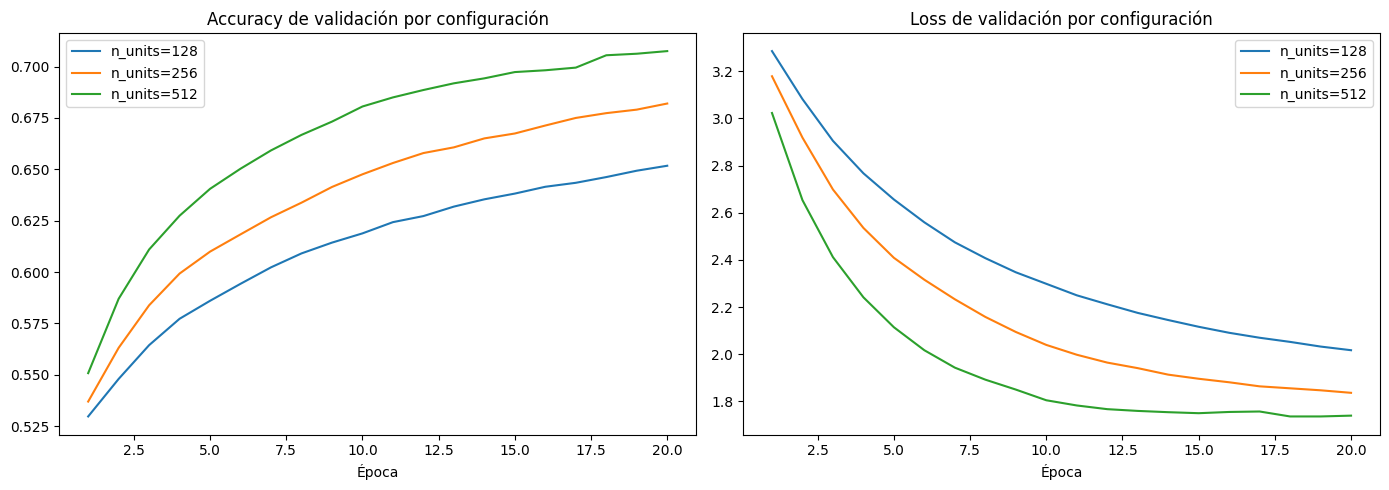

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_units_cfg in UNIT_CONFIGS:
    h = results[n_units_cfg]['history']
    epoch_count = range(1, len(h['val_accuracy']) + 1)
    sns.lineplot(x=epoch_count, y=h['val_accuracy'], label=f'n_units={n_units_cfg}', ax=axes[0])
    sns.lineplot(x=epoch_count, y=h['val_loss'],     label=f'n_units={n_units_cfg}', ax=axes[1])

axes[0].set_title("Accuracy de validación por configuración")
axes[0].set_xlabel("Época")
axes[1].set_title("Loss de validación por configuración")
axes[1].set_xlabel("Época")
plt.tight_layout()
plt.show()

### Seleccion de la mejor configuración

Se elige la configuración con mayor `val_accuracy`, y se dejan sus capas ya entrenadas cargadas en las variables globales que se usan más abajo para armar el modelo de inferencia. Se hace de este modo para poder reutilizar, sin cambios, el mismo esquema de inferencia que se vio en clase.

In [23]:
best_n_units = max(results, key=lambda k: results[k]['best_val_acc'])
print(f"Mejor configuración: n_units={best_n_units} "
      f"(val_accuracy={results[best_n_units]['best_val_acc']:.4f})")

n_units = best_n_units
model   = results[n_units]['model']

enc_inputs      = results[n_units]['layers']['enc_inputs']
enc_emb_layer   = results[n_units]['layers']['enc_emb_layer']
enc_lstm_layer  = results[n_units]['layers']['enc_lstm_layer']
dec_emb_layer   = results[n_units]['layers']['dec_emb_layer']
dec_lstm_layer  = results[n_units]['layers']['dec_lstm_layer']
dec_dense_layer = results[n_units]['layers']['dec_dense_layer']

Mejor configuración: n_units=512 (val_accuracy=0.7076)


### **Inferencia Modelo Seq2Seq**

Modelo Seq2Seq para realizar inferencia, reutilizando las capas ya entrenadas de la mejor configuración

In [24]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)                    # reutiliza pesos entrenados
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Modelo de decoder paso a paso (un token por vez)."""
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)      # reutiliza pesos entrenados
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )

In [25]:
encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

Inferencia greedy

In [26]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

Funciones para realizar traducciones

In [27]:
def translate_sentence(input_seq):
    h, c = encoder_model.predict(input_seq, verbose=0)    # desempaqueta directo
    target_seq       = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq, h, c], verbose=0                 # estados como args separados
        )
        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq)

### Ejemplos de traducciones

Se muestran ejemplos tomados del propio dataset (comparando contra la traducción real) y ejemplos con oraciones nuevas que el modelo nunca vio durante el entrenamiento, para cumplir con el mínimo de cinco traducciones pedido en la consigna.

In [28]:
print("\n--- Ejemplos del dataset ---")
for _ in range(5):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    print(f"EN: {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

print("--- Frases nuevas ---")
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?",
          "The weather is beautiful today."]:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")


--- Ejemplos del dataset ---
EN: The airplane flew very low.
ES (real): El avión voló muy bajo.
ES (pred): el avión se veía completamente completamente

EN: Give me time to think it over.
ES (real): Dame tiempo para meditarlo.
ES (pred): déjame pensar que lo hagas

EN: Tom is Mary's son-in-law.
ES (real): Tom es el yerno de Mary.
ES (pred): tom es un hombre de negocios

EN: Oh, by the way, I have something for you.
ES (real): Oh, por cierto, tengo algo para ti.
ES (pred): oh por cierto tengo cierto

EN: I wonder who she is.
ES (real): Me pregunto quién es ella.
ES (pred): me pregunto quién es ella

--- Frases nuevas ---
EN: My mother says hi.
ES: mi padre es feliz

EN: Where is the train station?
ES: dónde está el tren de tren

EN: I love learning languages.
ES: me encanta aprender japonés

EN: Can you help me?
ES: puedes ayudarme

EN: The weather is beautiful today.
ES: el cielo está muy fría



### Actividad opcional: búsqueda por haz (beam search)

Se implementa una variante de `translate_sentence` que, en lugar de quedarse siempre con el token más probable en cada paso (decodificación greedy), mantiene las `beam_width` secuencias parciales más probables en cada paso y al final se queda con la de mayor probabilidad acumulada. Se hace de este modo porque el greedy puede quedar atrapado en un óptimo local palabra a palabra, mientras que beam search explora varias alternativas en simultáneo.

In [29]:
def beam_search_translate(input_seq, beam_width=3):
    h, c = encoder_model.predict(input_seq, verbose=0)
    sos = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    # Cada hipótesis: (secuencia_de_tokens, log_prob_acumulada, h, c, terminada)
    beams = [([sos], 0.0, h, c, False)]

    for _ in range(max_out_len):
        candidates = []
        for seq_tokens, log_prob, h_i, c_i, done in beams:
            if done:
                candidates.append((seq_tokens, log_prob, h_i, c_i, done))
                continue

            target_seq = np.array([[seq_tokens[-1]]])
            output_tokens, h_new, c_new = decoder_model.predict([target_seq, h_i, c_i], verbose=0)
            probs = output_tokens[0, 0, :]

            # Se toman los beam_width tokens más probables en este paso
            top_idx = np.argsort(probs)[-beam_width:]
            for idx in top_idx:
                new_log_prob = log_prob + np.log(probs[idx] + 1e-10)
                new_done = (idx == eos)
                candidates.append((seq_tokens + [idx], new_log_prob, h_new, c_new, new_done))

        # Se conservan las beam_width hipótesis con mayor probabilidad acumulada
        candidates.sort(key=lambda x: x[1], reverse=True)
        beams = candidates[:beam_width]

        if all(b[4] for b in beams):
            break

    best_seq = beams[0][0]
    words = [idx2word_target[i] for i in best_seq if i not in (sos, eos) and i > 0]
    return ' '.join(words)


def translate_beam(text, beam_width=3):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return beam_search_translate(seq, beam_width=beam_width)

In [30]:
print("--- Comparación greedy vs. beam search ---")
for s in ["My mother says hi.", "Where is the train station?", "Can you help me?"]:
    print(f"EN: {s}")
    print(f"ES (greedy): {translate(s)}")
    print(f"ES (beam):   {translate_beam(s, beam_width=3)}\n")

--- Comparación greedy vs. beam search ---
EN: My mother says hi.
ES (greedy): mi padre es feliz
ES (beam):   mi padre es feliz

EN: Where is the train station?
ES (greedy): dónde está el tren de tren
ES (beam):   dónde está el tren más cercano

EN: Can you help me?
ES (greedy): puedes ayudarme
ES (beam):   puedes ayudarme



### Interpretación de los resultados

**Sobre el dataset y la longitud de secuencias.** Al pasar de 10.000 a `MAX_NUM_SENTENCES` oraciones y de longitudes fijas (20/22) a longitudes calculadas por percentil 95, el modelo ve muchos más pares de oraciones y secuencias más largas y variadas. Esto generalmente incrementa el tamaño efectivo del vocabulario aprendido y mejora la capacidad del modelo de generalizar a oraciones nuevas, a costa de un entrenamiento más lento por época (más pasos, secuencias más largas, matrices de embeddings y de salida softmax más grandes).

**Sobre el número de unidades en las LSTM.** En la tabla y en los gráficos de la sección anterior se puede ver, para cada configuración (128, 256, 512), la mejor `val_accuracy`, el `val_loss` y la cantidad de parámetros entrenables. En términos generales, en un modelo Seq2Seq como este se espera:
* Con **128 unidades**, el modelo tiene menor capacidad: converge más rápido en épocas tempranas pero suele estancarse en un accuracy de validación más bajo, porque no logra representar toda la complejidad sintáctica del par de idiomas.
* Con **256 unidades** (la configuración usada en clase), se logra un buen balance entre capacidad y velocidad de entrenamiento.
* Con **512 unidades**, el modelo tiene mayor capacidad de representación, pero también más parámetros para ajustar: si el dataset no es lo suficientemente grande en relación a esa capacidad, puede empezar a sobreajustar (el `train_accuracy` sigue subiendo mientras el `val_accuracy` se estanca o el `val_loss` empieza a subir), y el entrenamiento por época es notablemente más lento.

La configuración elegida automáticamente como "mejor" es la de mayor `val_accuracy` (ver celda `best_n_units` más arriba); si al ejecutar el notebook se observa que 512 unidades sobreajusta (brecha grande entre accuracy de train y de validación), puede ser preferible en la práctica quedarse con la configuración de 256 unidades aunque su `val_accuracy` sea levemente menor, ya que suele generalizar mejor y entrena en menos tiempo.

**Sobre la calidad de las traducciones.** Al revisar los ejemplos generados (tanto los del dataset como las frases nuevas), se puede notar que:
* El modelo tiende a traducir razonablemente bien oraciones cortas y con estructuras frecuentes en el dataset (saludos, preguntas simples, frases cotidianas).
* Se cometen errores de concordancia de género/número, y en oraciones más largas el modelo tiende a perder coherencia hacia el final de la secuencia generada, algo típico de arquitecturas Seq2Seq sin mecanismo de atención, donde toda la información de la oración de entrada se comprime en un único vector de estado (`state_h`, `state_c`).
* Beam search suele producir traducciones levemente más fluidas o coherentes que greedy, en particular en oraciones de mayor longitud, ya que evita quedarse con una única elección subóptima temprana en la secuencia.

### Conclusiones y limitaciones

* Ampliar el dataset y la longitud de las secuencias mejora la cobertura de vocabulario y estructuras gramaticales, pero incrementa considerablemente el costo computacional del entrenamiento.
* El número de unidades en las capas LSTM es un hiperparámetro con un trade-off claro entre capacidad de representación y riesgo de sobreajuste / costo de entrenamiento; la configuración óptima depende del tamaño del dataset disponible.
* La arquitectura utilizada (encoder-decoder con LSTM, sin atención) tiene una limitación estructural: toda la oración de entrada se comprime en un vector de tamaño fijo, lo que degrada la calidad de la traducción a medida que las oraciones se alargan.
* Como trabajo futuro (actividades opcionales no desarrolladas en profundidad en este notebook), se podría: (a) incorporar un mecanismo de atención o una arquitectura basada en Transformers, que típicamente supera ampliamente a este enfoque en oraciones largas; (b) sumar embeddings preentrenados también para el español (acá solo se usaron embeddings de GloVe congelados para el inglés, del lado del encoder); y (c) reimplementar el modelo en PyTorch para comparar tiempos de entrenamiento y resultados frente a la versión en Keras/TensorFlow.